[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/philogicae/timesfm_notebooks/blob/main/timesfm_crypto.ipynb)

# TimesFM Forecast

Forecast any time series with Google's TimesFM 2.5-200M. Returns a median path with a ±0.5-quantile confidence band.

**Sections:**
1. **Global** — deps, model, inference, display
2. **Data** — params, sources, conversion utils
3. **Execution** — source → prepare → infer → plot

# 1 · Global

## Dependencies & utilities

In [ ]:
# Install core system and model dependencies
!apt-get update && apt-get install -y libnss3 libnspr4 libatk1.0-0 libatk-bridge2.0-0 libcups2 libdrm2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2
!pip install -q timesfm "plotly>=6.1.1" plotly-geo kaleido pandas numpy
!plotly_get_chrome -y

import os
import time
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Configure environment for headless browser execution
CHROME_EXE = '/root/.local/share/choreographer/deps/chrome-linux64/chrome'
os.environ['KALEIDO_DISABLE_GPU'] = '1'
os.environ['CHROME_PATH'] = CHROME_EXE
os.environ['PLOTLY_KALEIDO_ARGS'] = '--no-sandbox --disable-gpu --single-process --disable-dev-shm-usage'

PALETTE = ['#F7931A', '#627EEA', '#00D39E', '#E84855', '#9D4EDD', '#F4A261',
           '#2EC4B6', '#E71D36', '#FF9F1C', '#011627']

def _color(sym, params, i):
    return params.get('colors', {}).get(sym) or PALETTE[i % len(PALETTE)]

def _hex_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

## Model

Loads once, persists in the kernel while you iterate below. Compile params fixed (TimesFM-recommended).

In [ ]:
def load_model():
    import timesfm
    print("Initializing google/timesfm-2.5-200m-pytorch...")
    model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        'google/timesfm-2.5-200m-pytorch')
    model.compile(timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    ))
    return model

tfm = load_model()

## Inference

Runs the model on each series' `Signal` column. Returns `dict[sym -> {med, lo, hi}]` of raw forecast arrays in whatever space `Signal` lives in.

In [ ]:
def run_inference(data, model, params):
    horizon = params['horizon']
    max_ctx = 1024
    results = {}
    for sym, df in data.items():
        inputs = df['Signal'].values.astype(np.float32)[-max_ctx:]
        _, qs = model.forecast(horizon=horizon, inputs=[inputs])
        q = qs[0]
        def interp(qv):
            i_lo, i_hi = int(np.floor(qv)), int(np.ceil(qv))
            return q[:, i_lo] if i_lo == i_hi else (i_hi - qv) * q[:, i_lo] + (qv - i_lo) * q[:, i_hi]
        results[sym] = {'med': interp(5), 'lo': interp(4.5), 'hi': interp(5.5)}
    return results

## Display

Dual log-scale axes, dashed median, shaded band, guide line at forecast start. Reads `data[sym]['Level']` for history and `results[sym][band]` for the forecast path.

In [ ]:
def plot_results(data, results, params):
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    horizon, rule = params['horizon'], params['resample_rule']
    primary = next(iter(data))

    # Get custom labels from params, fallback to symbol name
    labels = params.get('labels', {})

    for i, (sym, df) in enumerate(data.items()):
        on_secondary = sym != primary
        res = results[sym]
        dates = pd.date_range(df.index[-1], periods=horizon + 1, freq=rule).strftime('%Y-%m-%d').tolist()
        history_dates = df.index.strftime('%Y-%m-%d').tolist()

        y_vals = {k: np.concatenate(([df['Level'].iloc[-1]], v)) for k, v in res.items()}
        color = _color(sym, params, i)
        r, g, b = _hex_rgb(color)

        fig.add_trace(go.Scatter(x=dates, y=y_vals['hi'], line_width=0, showlegend=False, hoverinfo='skip'), secondary_y=on_secondary)
        fig.add_trace(go.Scatter(x=dates, y=y_vals['lo'], line_width=0, fill='tonexty',
                                 fillcolor=f'rgba({r},{g},{b},0.25)', showlegend=False, hoverinfo='skip'), secondary_y=on_secondary)
        fig.add_trace(go.Scatter(x=history_dates, y=df['Level'], name=sym,
                                 line=dict(color=color, width=1.5), showlegend=False), secondary_y=on_secondary)
        fig.add_trace(go.Scatter(x=dates, y=y_vals['med'], name=f'{sym} forecast',
                                 line=dict(color=color, dash='dot', width=2), showlegend=False), secondary_y=on_secondary)

        # Update specific Y-axis title based on whether it's primary or secondary
        title = labels.get(sym, sym)
        if on_secondary:
            fig.update_yaxes(title_text=title, secondary_y=True)
        else:
            fig.update_yaxes(title_text=title, secondary_y=False)

    last_date = max(df.index[-1] for df in data.values()).strftime('%Y-%m-%d')

    fig.update_layout(
        template='plotly_dark', title=f"TimesFM Forecast · {horizon}×{rule} horizon",
        showlegend=False, hovermode='x unified',
        width=1280, height=720,
        shapes=[dict(type='line', xref='x', x0=last_date, x1=last_date,
                     yref='paper', y0=0, y1=1, line=dict(color='white', width=1, dash='dash'))],
    )
    fig.update_yaxes(type='log')
    fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.05))

    try:
        fig.write_image('timesfm_crypto.png')
    except Exception as e:
        print(f"Warning: Image not saved. {e}")

    fig.show()

# 2 · Data

## Parameters

In [ ]:
PARAMS = {
    'symbols': ['BTC-USD', 'ETH-USD'],
    'resample_rule': '3D', # 3-day timeframe
    'horizon': 250,
    'colors': {'BTC-USD': '#F7931A', 'ETH-USD': '#627EEA'},
    'labels': {'BTC-USD': 'BTC', 'ETH-USD': 'ETH'} # Custom axis labels
}

## Sources

Each returns `dict[str, pd.Series]` with a `DatetimeIndex`. Write your own — DB query, API, synthetic generator — as long as it returns this.

In [ ]:
# Install data-specific dependencies
!pip install -q yfinance

def from_yfinance(symbols, period='max'):
    import yfinance as yf
    out = {}
    for sym in symbols:
        df = yf.download(sym, period=period, interval='1d', progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        out[sym] = df['Close']
    start = max(s.index[0] for s in out.values())
    return {sym: s[s.index >= start] for sym, s in out.items()}

def from_csv(path, name=None, date_col=0):
    from pathlib import Path
    p = Path(path)
    df = pd.read_csv(p, parse_dates=[date_col], index_col=date_col)
    return {name or p.stem: df['Close']}

def from_dict(values, name='series', start=None, freq='1D'):
    values = np.asarray(values, dtype=float)
    idx = pd.date_range(start or pd.Timestamp.now() - pd.Timedelta(days=len(values)-1),
                        periods=len(values), freq=freq)
    return {name: pd.Series(values, index=idx, name='Close')}

## Utils

Residual-space transform for price-like series: resample → log returns → rolling volatility → normalized residuals. `prepare_series` emits `Level` (history) and `Signal` (what the model sees). `to_levels` maps raw forecasts back to level space via the last value and trailing volatility. Swap this block to forecast in a different space (e.g. put raw levels in `Signal` and make `to_levels` the identity).

In [ ]:
def prepare_series(close, params):
    s = close.resample(params['resample_rule']).last().interpolate(method='pchip')
    lr = np.log(s / s.shift(1)).fillna(0)
    vol = lr.rolling(20).std().ffill().fillna(lr.std())
    return pd.DataFrame({'Level': s, 'Vol': vol, 'Signal': lr / vol})

def prepare_all(raw, params):
    return {sym: prepare_series(s, params) for sym, s in raw.items()}

def to_levels(df, fcst):
    last, vol = df['Level'].iloc[-1], df['Vol'].iloc[-1]
    return {k: last * np.exp(np.cumsum(v * vol)) for k, v in fcst.items()}

# 3 · Execution

## Run

Pick a source (one `raw = ...` line), then prepare → infer → denormalize → plot.

In [ ]:
t0 = time.time()

# --- Pick a source (uncomment one) ---
raw = from_yfinance(PARAMS['symbols'])
# raw = from_csv('my_series.csv', name='MY')
# raw = from_dict(np.cumsum(np.random.randn(300)) + 100, name='synthetic')

print(f"[1/3] Loaded {len(raw)} series: {', '.join(raw)} ({time.time()-t0:.1f}s)")
t1 = time.time()

print("[2/3] Preparing + inference...")
data = prepare_all(raw, PARAMS)
raw_preds = run_inference(data, tfm, PARAMS)
preds = {sym: to_levels(data[sym], raw_preds[sym]) for sym in raw_preds}
print(f"      done ({time.time()-t1:.1f}s)")
t2 = time.time()

print("[3/3] Rendering chart...")
plot_results(data, preds, PARAMS)
print(f"✓ total {time.time()-t0:.1f}s")

## Persisted chart

Saved as `timesfm_crypto.png` on each run so it renders on GitHub without re-executing.

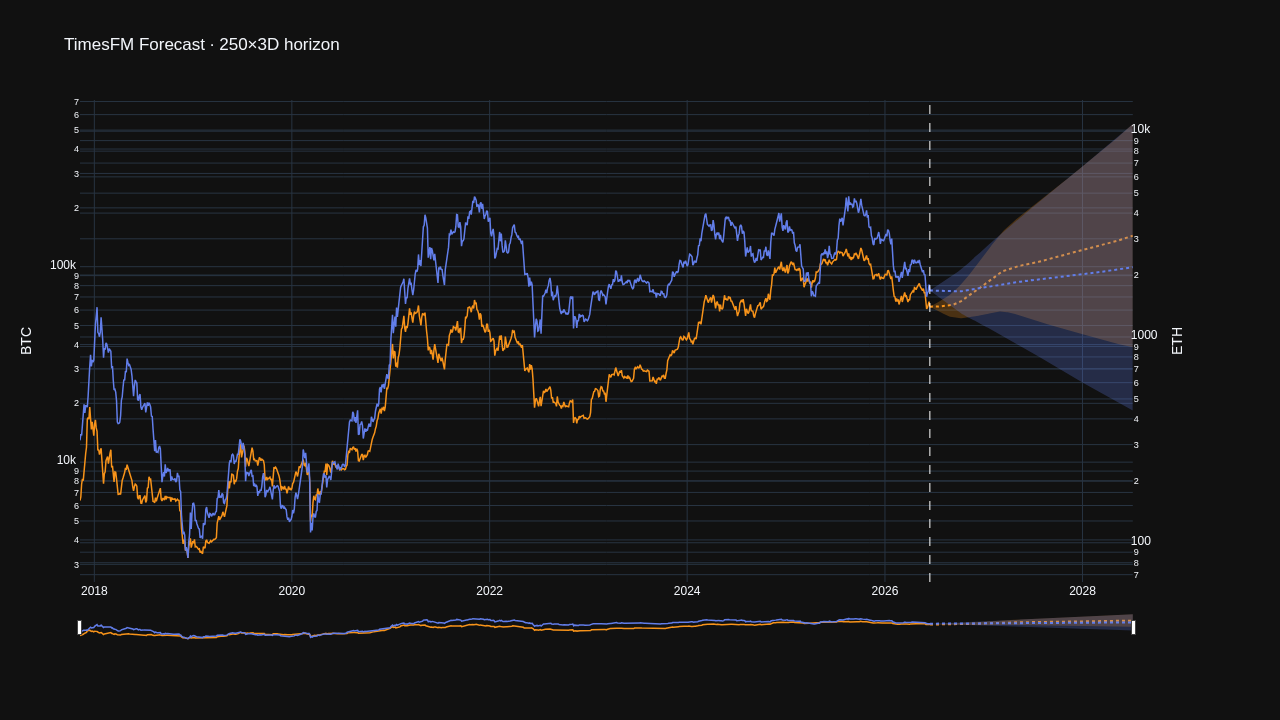

In [ ]:
import os
from IPython.display import Image, display

PNG = 'timesfm_crypto.png'
if os.path.exists(PNG):
    display(Image(PNG))
else:
    print(f"Note: '{PNG}' not found. Please run the 'Execution' cell above to generate it.")